In [2]:
!pip install xgboost
!pip install shap
!pip install imbalanced-learn
!pip install streamlit
!pip install joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 85.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 51.3 MB/s eta 0:00:00


In [ ]:
# Force install older scikit-learn that works with Streamlit Cloud
#!pip uninstall scikit-learn -y
#!pip install scikit-learn==1.2.2

In [3]:
import warnings
warnings.filterwarnings('ignore') # hide annoying pandas/sklearn warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

# sklearn stuff
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# metrics - added average_precision for the imbalanced data handling
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, average_precision_score, classification_report
)

# need imblearn pipeline to prevent data leakage when using SMOTE
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline # just in case standard pipeline is needed later

# notebook adjustments
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

print("Setup complete.")

Setup complete.


In [5]:
import sklearn
print(sklearn.__version__)

1.6.1


In [6]:
from google.colab import files


uploaded = files.upload()

# Check if uploaded successfully
for filename in uploaded.keys():
    print(f"Uploaded: {filename}")

# Load the dataset
df = pd.read_csv(list(uploaded.keys())[0])

# Display basic info
print(f"\n Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nFirst 5 rows:")
df.head()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv
Uploaded: WA_Fn-UseC_-Telco-Customer-Churn.csv

 Dataset shape: 7043 rows, 21 columns

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
# Check data types
print("Data Types:")
print(df.dtypes)

print("\n Missing Values:")
print(df.isnull().sum())

print("\n Basic Statistics:")
df.describe()

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

 Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
# Step 1: Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many became NaN
missing_total = df['TotalCharges'].isnull().sum()
print(f"Missing TotalCharges values: {missing_total}")

# Step 2: Drop CustomerID (useless for prediction)
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# Step 3: Convert Churn to binary (Yes→1, No→0)
df['Churn'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Check churn rate
churn_rate = df['Churn'].mean() * 100
print(f"\n Churn rate: {churn_rate:.1f}%")


Missing TotalCharges values: 11

 Churn rate: 26.5%


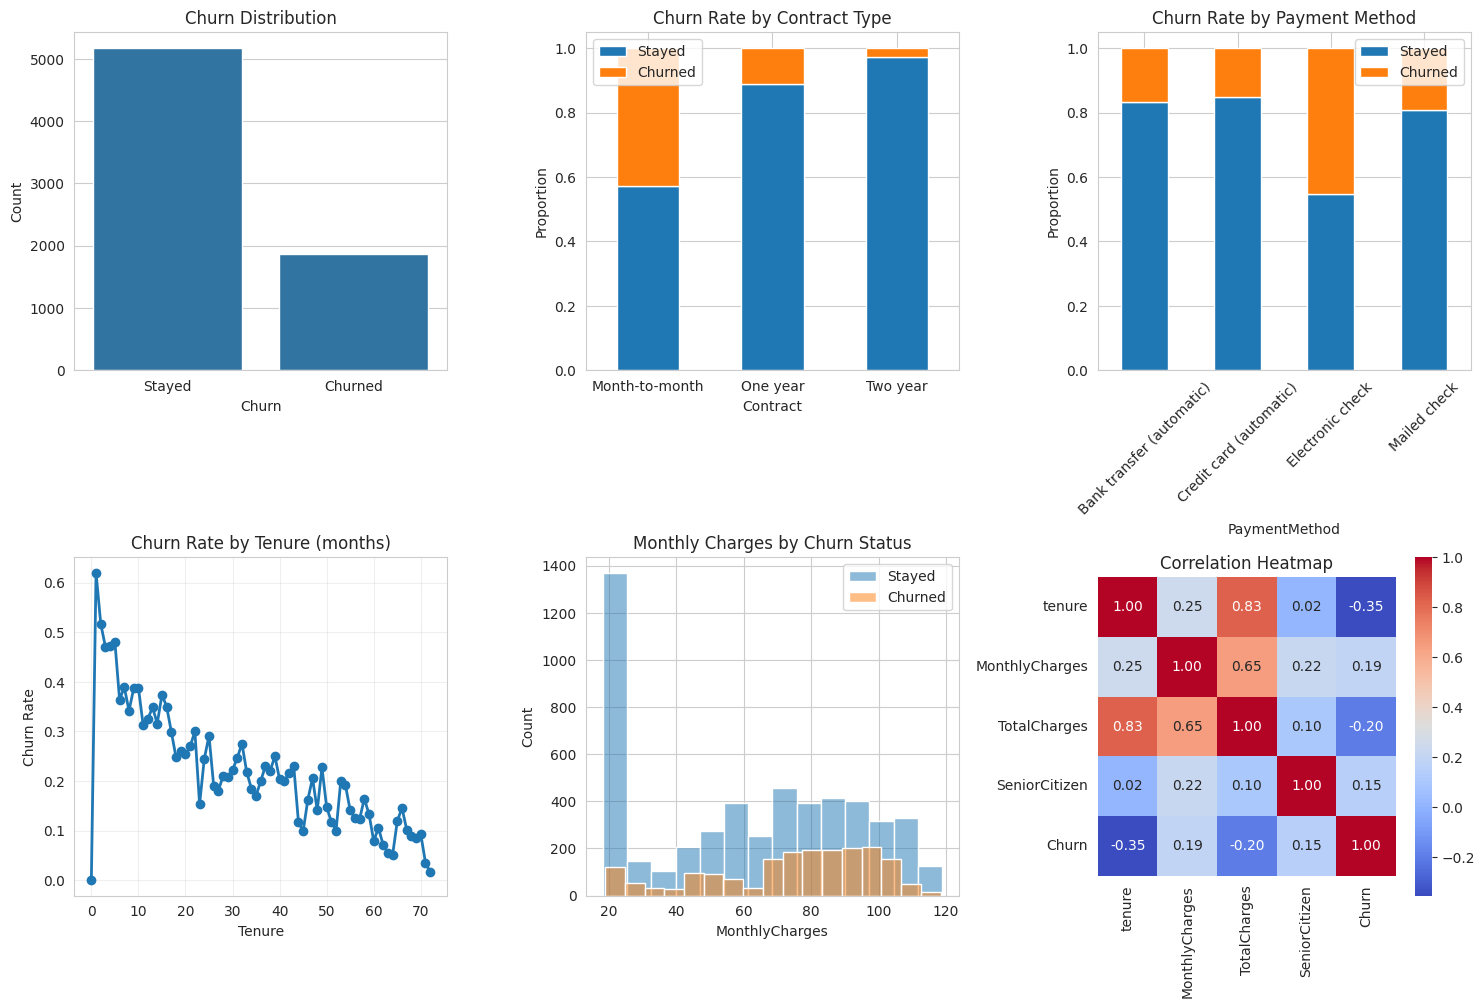

In [9]:
# Create a figure with multiple subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot 1: Churn Distribution
sns.countplot(data=df, x='Churn', ax=axes[0,0])
axes[0,0].set_title('Churn Distribution')
axes[0,0].set_xticklabels(['Stayed', 'Churned'])
axes[0,0].set_ylabel('Count')

# Plot 2: Churn by Contract Type
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index')
contract_churn.plot(kind='bar', stacked=True, ax=axes[0,1])
axes[0,1].set_title('Churn Rate by Contract Type')
axes[0,1].set_ylabel('Proportion')
axes[0,1].legend(['Stayed', 'Churned'])
axes[0,1].tick_params(axis='x', rotation=0)

# Plot 3: Churn by Payment Method
payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index')
payment_churn.plot(kind='bar', stacked=True, ax=axes[0,2])
axes[0,2].set_title('Churn Rate by Payment Method')
axes[0,2].set_ylabel('Proportion')
axes[0,2].legend(['Stayed', 'Churned'])
axes[0,2].tick_params(axis='x', rotation=45)

# Plot 4: Churn by Tenure
tenure_churn = df.groupby('tenure')['Churn'].mean()
axes[1,0].plot(tenure_churn.index, tenure_churn.values, marker='o', linewidth=2)
axes[1,0].set_title('Churn Rate by Tenure (months)')
axes[1,0].set_xlabel('Tenure')
axes[1,0].set_ylabel('Churn Rate')
axes[1,0].grid(True, alpha=0.3)

# Plot 5: Monthly Charges Distribution by Churn
for churn_val in [0, 1]:
    subset = df[df['Churn'] == churn_val]['MonthlyCharges']
    label = 'Churned' if churn_val == 1 else 'Stayed'
    sns.histplot(subset, label=label, alpha=0.5, ax=axes[1,1])
axes[1,1].set_title('Monthly Charges by Churn Status')
axes[1,1].legend()

# Plot 6: Correlation Heatmap
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm',
            fmt='.2f', square=True, ax=axes[1,2])
axes[1,2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('eda_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()


In [10]:
# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split FIRST - prevents data leakage!
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42,    # Reproducible results
    stratify=y          # Maintains churn rate in both sets
)

print(f" Training set: {X_train.shape[0]} rows")
print(f" Test set: {X_test.shape[0]} rows")
print(f"\nTraining churn rate: {y_train.mean()*100:.1f}%")
print(f"Test churn rate: {y_test.mean()*100:.1f}%")

 Training set: 5634 rows
 Test set: 1409 rows

Training churn rate: 26.5%
Test churn rate: 26.5%


In [11]:
# numbers
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

# everything else
categorical_features = [col for col in X.columns if col not in numeric_features]

print(f" Numeric features ({len(numeric_features)}):")
print(f"   {numeric_features}")

print(f"\n Categorical features ({len(categorical_features)}):")
print(f"   {categorical_features}")

 Numeric features (3):
   ['tenure', 'MonthlyCharges', 'TotalCharges']

 Categorical features (16):
   ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [12]:
# Numeric pipeline: Impute missing values (median) + Scale
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Uses median from TRAIN only
    ('scaler', StandardScaler())                    # Uses mean/std from TRAIN only
])

# Categorical pipeline: Impute missing + One-Hot Encode
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Combine in ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [13]:
# Calculate Class Imbalance Weight


# For XGBoost scale_pos_weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f" Class imbalance ratio (non-churners / churners): {scale_pos_weight:.2f}")
print(f"   This means churners are weighted {scale_pos_weight:.2f}x more than non-churners")

 Class imbalance ratio (non-churners / churners): 2.77
   This means churners are weighted 2.77x more than non-churners


In [14]:

# Model 1: Logistic Regression (with class weights)
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',   # Handles imbalance
        max_iter=1000,
        random_state=42
    ))
])

# Model 2: Random Forest (with class weights)
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        class_weight='balanced',   # Handles imbalance
        n_estimators=100,
        random_state=42
    ))
])

# Model 3: XGBoost (with scale_pos_weight)
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        scale_pos_weight=scale_pos_weight,  # Handles imbalance
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    ))
])

print(" 3 model pipelines created:")
print("   1. Logistic Regression (with class_weight='balanced')")
print("   2. Random Forest (with class_weight='balanced')")
print("   3. XGBoost (with scale_pos_weight={:.2f})".format(scale_pos_weight))

 3 model pipelines created:
   1. Logistic Regression (with class_weight='balanced')
   2. Random Forest (with class_weight='balanced')
   3. XGBoost (with scale_pos_weight=2.77)


In [15]:

#Train All Models


models = {
    'Logistic Regression': lr_pipeline,
    'Random Forest': rf_pipeline,
    'XGBoost': xgb_pipeline
}

results = {}

print(" Training models...")
print("="*50)

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Store results
    results[name] = {
        'model': model,
        'predictions': y_pred,
        'probabilities': y_proba
    }

    print(f" {name} training complete!")

print("\n" + "="*50)
print(" All 3 models trained successfully!")

 Training models...

Training Logistic Regression...
 Logistic Regression training complete!

Training Random Forest...
 Random Forest training complete!

Training XGBoost...
 XGBoost training complete!

 All 3 models trained successfully!


In [16]:

#  Hyperparameter Tuning (GridSearchCV)


print(" Starting hyperparameter tuning for XGBoost...")


# Define parameter grid
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1, 0.3],
    'classifier__subsample': [0.6, 0.8, 1.0],
    'classifier__colsample_bytree': [0.6, 0.8, 1.0]
}

# Create XGBoost pipeline (same as before)
xgb_base = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    ))
])

# Grid search
grid_search = GridSearchCV(
    xgb_base,
    param_grid,
    cv=5,                    # 5-fold cross-validation
    scoring='roc_auc',       # Optimize ROC-AUC
    n_jobs=-1,               # Use all CPU cores
    verbose=1                # Show progress
)

# Fit (this takes time!)
grid_search.fit(X_train, y_train)

# Best parameters
print("\n" + "="*50)
print(" Best Parameters Found:")
print("="*50)
for param, value in grid_search.best_params_.items():
    print(f"{param}: {value}")

print(f"\nBest Cross-Validation ROC-AUC: {grid_search.best_score_:.4f}")

# Update XGBoost in results with tuned version
xgb_tuned = grid_search.best_estimator_
results['XGBoost (Tuned)'] = {
    'model': xgb_tuned,
    'predictions': xgb_tuned.predict(X_test),
    'probabilities': xgb_tuned.predict_proba(X_test)[:, 1]
}

# Replace original XGBoost with tuned version
del results['XGBoost']
results['XGBoost'] = results.pop('XGBoost (Tuned)')

print(" Hyperparameter tuning complete!")

 Starting hyperparameter tuning for XGBoost...
Fitting 5 folds for each of 243 candidates, totalling 1215 fits

 Best Parameters Found:
classifier__colsample_bytree: 0.8
classifier__learning_rate: 0.1
classifier__max_depth: 3
classifier__n_estimators: 50
classifier__subsample: 0.6

Best Cross-Validation ROC-AUC: 0.8488
 Hyperparameter tuning complete!


In [17]:
#
# Comprehensive Model Evaluation


# Calculate all metrics for each model
comparison_data = []

for name, result in results.items():
    y_pred = result['predictions']
    y_proba = result['probabilities']

    comparison_data.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'PR-AUC': average_precision_score(y_test, y_proba)
    })

# Create comparison table
comparison_df = pd.DataFrame(comparison_data)

print("="*80)
print(" MODEL COMPARISON TABLE")
print("="*80)
print(comparison_df.round(4))

# Find best model
best_row = comparison_df.loc[comparison_df['ROC-AUC'].idxmax()]
best_model_name = best_row['Model']
best_model = results[best_model_name]['model']

print(f"\n BEST MODEL: {best_model_name}")
print(f"   ROC-AUC: {best_row['ROC-AUC']:.4f}")
print(f"   PR-AUC: {best_row['PR-AUC']:.4f}")
print(f"   F1-Score: {best_row['F1-Score']:.4f}")

# Save comparison table for report
comparison_df.round(4).to_csv('model_comparison.csv', index=False)
print("\n Comparison table saved as 'model_comparison.csv'")

 MODEL COMPARISON TABLE
                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  PR-AUC
0  Logistic Regression    0.7388     0.5052  0.7834    0.6143   0.8417  0.6331
1        Random Forest    0.7921     0.6401  0.4947    0.5581   0.8253  0.6256
2              XGBoost    0.7410     0.5075  0.8155    0.6256   0.8469  0.6612

 BEST MODEL: XGBoost
   ROC-AUC: 0.8469
   PR-AUC: 0.6612
   F1-Score: 0.6256

 Comparison table saved as 'model_comparison.csv'


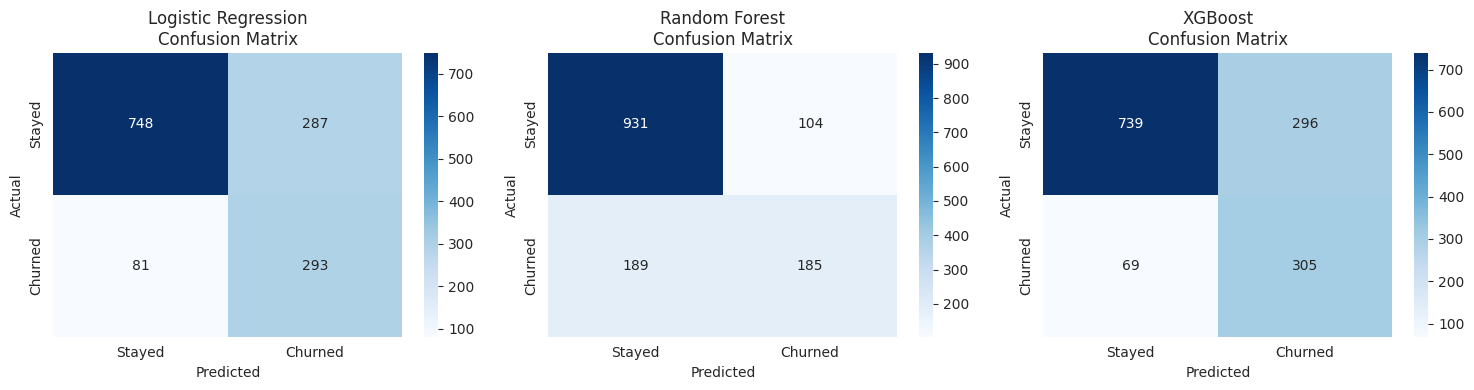

 Confusion matrices saved as 'confusion_matrices.png'


In [18]:
# Confusion Matrices

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result['predictions'])

    # Plot heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Stayed', 'Churned'],
                yticklabels=['Stayed', 'Churned'])
    axes[idx].set_title(f'{name}\nConfusion Matrix')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Confusion matrices saved as 'confusion_matrices.png'")

In [19]:

# Cross-Validation (Stability Check)


cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='roc_auc')

print("="*50)
print(f" 5-Fold Cross-Validation: {best_model_name}")
print("="*50)
print(f"Individual fold scores: {cv_scores}")
print(f"\nMean ROC-AUC: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")
print(f"95% Confidence Interval: [{cv_scores.mean() - 1.96*cv_scores.std():.4f}, "
      f"{cv_scores.mean() + 1.96*cv_scores.std():.4f}]")

 5-Fold Cross-Validation: XGBoost
Individual fold scores: [0.8610504  0.85946679 0.83534191 0.84068203 0.84711778]

Mean ROC-AUC: 0.8487
Standard Deviation: 0.0101
95% Confidence Interval: [0.8289, 0.8686]


In [20]:
# SHAP Analysis (Explainable AI)


print(" Generating SHAP explanations...")

# Extract the XGBoost model
xgb_model = best_model.named_steps['classifier']

# Get preprocessed data
X_test_processed = best_model.named_steps['preprocessor'].transform(X_test)

# Get feature names
feature_names = (numeric_features +
                 list(best_model.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .get_feature_names_out(categorical_features)))

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values (takes ~30 seconds)
shap_values = explainer.shap_values(X_test_processed)

# Plot 1: Summary Plot (shows top features)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_processed, feature_names=feature_names,
                  max_display=15, show=False)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.close()

# Plot 2: Bar Plot (feature importance)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_processed, feature_names=feature_names,
                  plot_type='bar', max_display=15, show=False)
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.close()

print(" SHAP plots saved:")
print("   - shap_summary.png (shows feature effects)")
print("   - shap_importance.png (feature importance)")

 Generating SHAP explanations...
 SHAP plots saved:
   - shap_summary.png (shows feature effects)
   - shap_importance.png (feature importance)


In [21]:
 #Save Model

# Save the best model
joblib.dump(best_model, 'model.pkl')

# Also save preprocessor separately (for backup)
joblib.dump(preprocessor, 'preprocessor.pkl')

print(" Model saved as 'model.pkl'")
print(" Preprocessor saved as 'preprocessor.pkl'")

# Verify model loads correctly
test_load = joblib.load('model.pkl')
print(" Verification: Model loads successfully")

 Model saved as 'model.pkl'
 Preprocessor saved as 'preprocessor.pkl'
 Verification: Model loads successfully


In [23]:
import pickle

# Save with protocol 4 (more compatible)
with open('model.pkl', 'wb') as f:
    pickle.dump(best_model, f, protocol=4)

# Download
from google.colab import files
files.download('model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
# ==============================================
# CELL 19: Download All Files
# ==============================================

from google.colab import files

# Files to download
files_to_download = [
    'model.pkl',
    'preprocessor.pkl',
    'eda_visualizations.png',
    'confusion_matrices.png',
    'shap_summary.png',
    'shap_importance.png',
    'model_comparison.csv'
]

print("📥 Downloading files...")
for file in files_to_download:
    try:
        files.download(file)
        print(f"✅ Downloaded: {file}")
    except:
        print(f"⚠️ Could not download: {file}")

print("\n✅ All files downloaded!")

📥 Downloading files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: model.pkl


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Downloaded: shap_importance.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: model_comparison.csv

✅ All files downloaded!
